Loading and Preprocessing

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display first few rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### KMeans Clustering

KMeans is a centroid-based clustering algorithm that partitions data into K clusters by minimizing the variance within each cluster. It works by:

1. Initializing K centroids randomly

2. Assigning each data point to the nearest centroid

3. Updating centroids by computing the mean of all assigned points

4. Repeating steps 2 and 3 until convergence

Why Suitable:
The Iris dataset has three natural groupings (species), and KMeans can reveal these clusters effectively by grouping data based on feature similarity.

C:\Users\rahul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


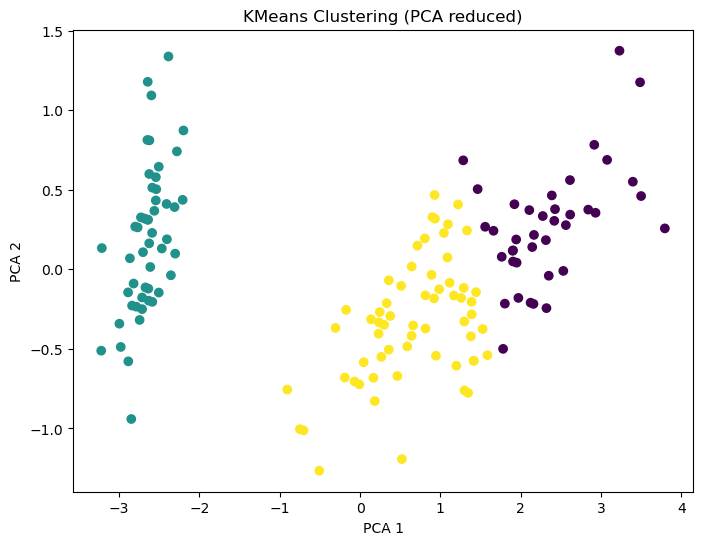

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(df)

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df[iris.feature_names])
df['pca1'] = reduced_data[:, 0]
df['pca2'] = reduced_data[:, 1]

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(df['pca1'], df['pca2'], c=df['kmeans_cluster'], cmap='viridis')
plt.title('KMeans Clustering (PCA reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


### 2. Hierarchical Clustering

Description:
Hierarchical Clustering creates a tree-like structure (dendrogram) to group data points. It can be:

1. Agglomerative (bottom-up): start with each point as a cluster, then merge.

2. Divisive (top-down): start with one cluster, then split.

Linkage methods (e.g., Ward's, complete, average) decide how distances between clusters are measured.

Why Suitable:
The Iris dataset's small size and natural grouping make it well-suited for hierarchical clustering, allowing us to visualize the nested structure via dendrograms.

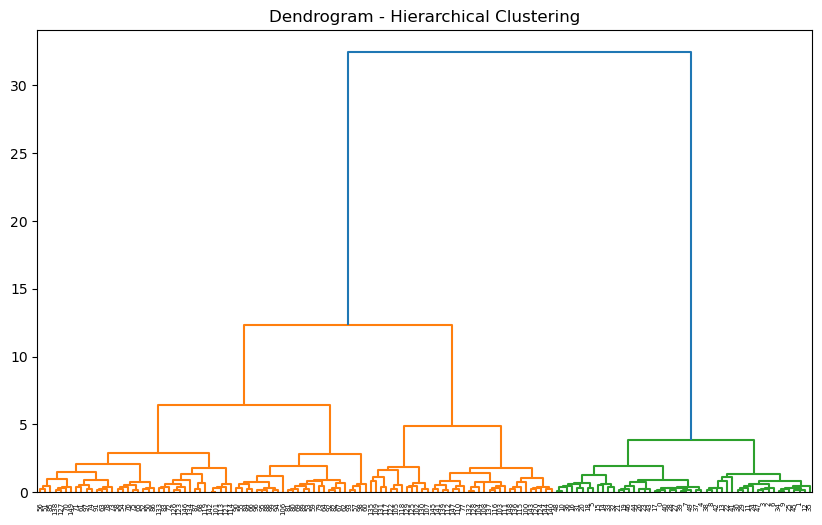

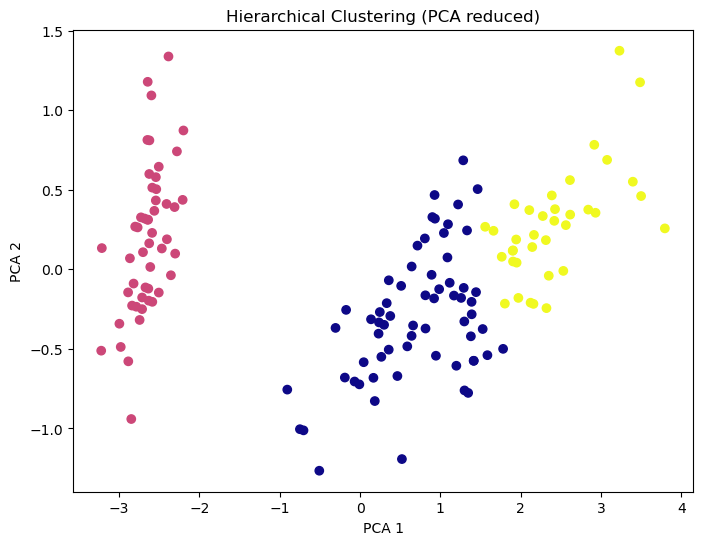

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Create linkage matrix and plot dendrogram
linked = linkage(df[iris.feature_names], method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Dendrogram - Hierarchical Clustering")
plt.show()

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3)
df['hierarchical_cluster'] = agg_clustering.fit_predict(df[iris.feature_names])

# Plot Hierarchical Clustering results using PCA
plt.figure(figsize=(8,6))
plt.scatter(df['pca1'], df['pca2'], c=df['hierarchical_cluster'], cmap='plasma')
plt.title('Hierarchical Clustering (PCA reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()
